Property Object Detection


In [1]:
#Unzip datasets
import zipfile, os

def unzip(zip_path, extract_to):
  os.makedirs(extract_to, exist_ok=True)
  with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)
  print("✅ unzipped:", zip_path, "-", extract_to)
  print("📁 Top files:", os.listdir(extract_to)[:10])

unzip("/content/satellite_dataset_new.zip", "/content/satellite_dataset_new")
unzip("/content/street_view_dataset_new.zip", "/content/street_view_dataset_new")

✅ unzipped: /content/satellite_dataset_new.zip - /content/satellite_dataset_new
📁 Top files: ['val', 'test', 'train', 'data.yaml', 'metadata.csv']
✅ unzipped: /content/street_view_dataset_new.zip - /content/street_view_dataset_new
📁 Top files: ['val', 'test', 'train', 'data.yaml', 'metadata.csv']


In [2]:
#Install Deep Learning libraries

#install tensorflow
!pip -q install tensorflow

#import libraries
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
#Function 1 - Satellite land-cover classification model training (CNN)

#load dataset
SAT_BASE = "/content/satellite_dataset_new"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
SEED = 42

sat_train = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SAT_BASE, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

sat_val = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SAT_BASE, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

sat_test = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SAT_BASE, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

sat_class_names = sat_train.class_names
sat_class_names

Found 1243 files belonging to 3 classes.
Found 265 files belonging to 3 classes.
Found 269 files belonging to 3 classes.


['bare_lands', 'buildings', 'vegetations']

In [4]:
#Improve performance and training speed(prefetch).
#Optimize how data is loaded during model training and evaluation.
#prefetch() = allows data loading and model training to run in parallel.
#AUTOTUNE = Automatically decide the best buffer size based on system resources.
AUTOTUNE = tf.data.AUTOTUNE

sat_train = sat_train.prefetch(buffer_size=AUTOTUNE)
sat_val = sat_val.prefetch(buffer_size=AUTOTUNE)
sta_test = sat_test.prefetch(buffer_size=AUTOTUNE)

In [5]:
#Build the CNN model
def build_cnn(num_classes):
  model = tf.keras.Sequential([
      layers.Rescaling(1./255, input_shape=(128,128,3)),

      layers.Conv2D(32, 3, activation='relu'),
      layers.MaxPooling2D(),

      layers.Conv2D(64, 3, activation='relu'),
      layers.MaxPooling2D(),

      layers.Conv2D(128, 3, activation='relu'),
      layers.MaxPooling2D(),

      layers.Dropout(0.3),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(num_classes, activation='softmax')
  ])
  return model

sat_model = build_cnn(num_classes=len(sat_class_names))
sat_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

sat_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#Train the model
#5 epochs
sat_history = sat_model.fit(
    sat_train,
    validation_data=sat_val,
    epochs=5
)

Epoch 1/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.6509 - loss: 0.7527 - val_accuracy: 0.8755 - val_loss: 0.3105
Epoch 2/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.9130 - loss: 0.2599 - val_accuracy: 0.9321 - val_loss: 0.1661
Epoch 3/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.9567 - loss: 0.1150 - val_accuracy: 0.9434 - val_loss: 0.1406
Epoch 4/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.9611 - loss: 0.0969 - val_accuracy: 0.9396 - val_loss: 0.1322
Epoch 5/5
39/39 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9574 - loss: 0.1064 - val_accuracy: 0.9396 - val_loss: 0.1552


In [7]:
#Test Accuracy
sat_test_loss, sat_test_acc = sat_model.evaluate(sat_test)
print("✅ Satellite Test Accuracy:", sat_test_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 709ms/step - accuracy: 0.9822 - loss: 0.0685
✅ Satellite Test Accuracy: 0.9553903341293335


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step


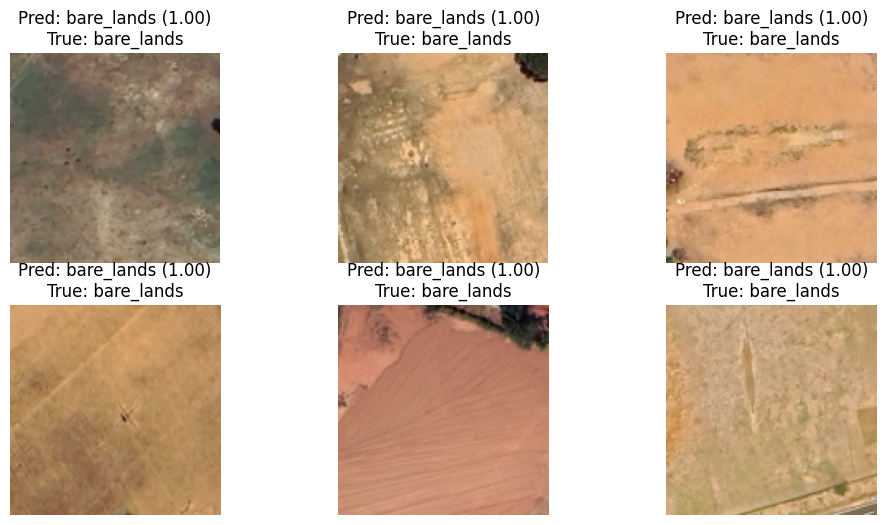

In [8]:
#Predict on a few images
import itertools

def show_predictions(dataset, model, class_names, n=6):
  plt.figure(figsize=(12,6))
  for images, labels in dataset.take(1):
    preds = model.predict(images)
    for i in range(n):
      ax = plt.subplot(2, 3, i+1)
      plt.imshow(images[i].numpy().astype("uint8"))
      pred_class = class_names[np.argmax(preds[i])]
      true_class = class_names[labels[i]]
      conf = float(np.max(preds[i]))
      plt.title(f"Pred: {pred_class} ({conf:.2f})\nTrue: {true_class}")
      plt.axis("off")
  plt.show()

show_predictions(sat_test, sat_model, sat_class_names, n=6)

In [9]:
#Function 2 - Street View property context classification model training

#load dataset
ST_BASE = "/content/street_view_dataset_new"

st_train = tf.keras.utils.image_dataset_from_directory(
    os.path.join(ST_BASE, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

st_val = tf.keras.utils.image_dataset_from_directory(
    os.path.join(ST_BASE, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

st_test = tf.keras.utils.image_dataset_from_directory(
    os.path.join(ST_BASE, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

st_class_names = st_train.class_names
st_class_names

Found 1260 files belonging to 3 classes.
Found 270 files belonging to 3 classes.
Found 270 files belonging to 3 classes.


['boundary_wall_gates', 'building_front', 'vegetation']

In [10]:
#Train the model
st_train = st_train.prefetch(AUTOTUNE)
st_val = st_val.prefetch(AUTOTUNE)
st_test = st_test.prefetch(AUTOTUNE)

st_model = build_cnn(num_classes=len(st_class_names))
st_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

st_history = st_model.fit(
    st_train,
    validation_data=st_val,
    epochs=5
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.4225 - loss: 1.1541 - val_accuracy: 0.8111 - val_loss: 0.4652
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.8130 - loss: 0.4860 - val_accuracy: 0.8926 - val_loss: 0.3250
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8683 - loss: 0.3300 - val_accuracy: 0.7778 - val_loss: 0.6581
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8881 - loss: 0.3387 - val_accuracy: 0.8963 - val_loss: 0.2441
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9261 - loss: 0.2023 - val_accuracy: 0.9259 - val_loss: 0.1588


9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 399ms/step - accuracy: 0.9323 - loss: 0.2070
✅ Street View Test Accuracy: 0.9518518447875977
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step


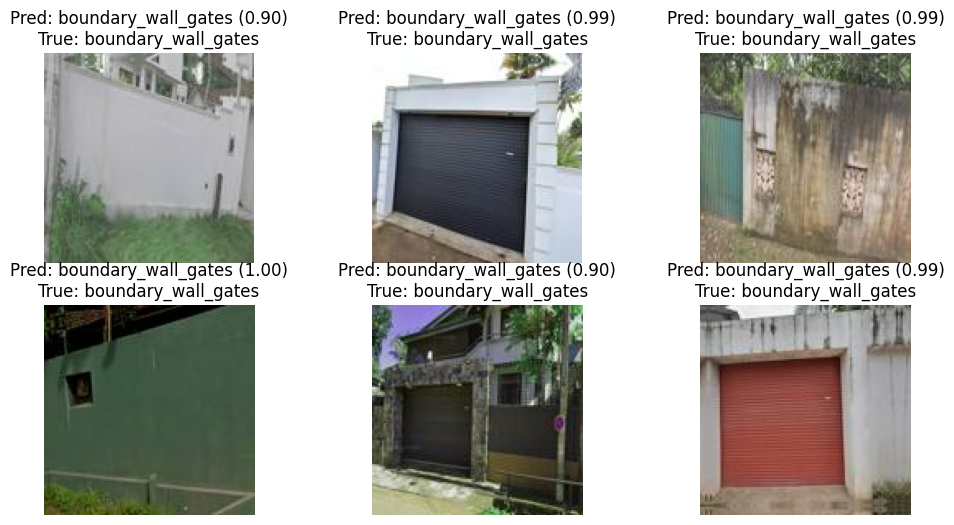

In [11]:
#Evaluation and sample predictions
st_test_loss, st_test_acc = st_model.evaluate(st_test)
print("✅ Street View Test Accuracy:", st_test_acc)

show_predictions(st_test, st_model, st_class_names, n=6)

In [12]:
import numpy as np
import tensorflow as tf

In [13]:
#A simple rating valuation calculation
#This is not the full municipal formula, I do only a demo.
#Here I used factors for only for demo purposes.
#Idea is,
  #buildings - higher rate
  #bare lands - medium rate
  #vegetation - lower rate
  #building front - higher rate
  #boundary wall gates - mediaum rate
#Here I used model prediction to select a rate factor and compute a valuation score

#Simple valuation rule(demo only)
SAT_VALUATION_FACTOR = {
    "buildings": 1.8,
    "bare_lands": 1.0,
    "vegetations": 0.7
}

ST_VALUATION_FACTOR = {
    "building_front": 1.6,
    "boundary_wall_gates": 1.2,
    "vegetation": 0.7
}

def estimate_value(area_sq_m, predicted_class, factor_map, base_rate=1200):
  """
  Demo valuation: Annual Value Score = base_rate * area * factor
  (Not official CMC factor or formula: Only for my research prototype)
  """
  factor = factor_map.get(predicted_class, 1.0)
  return base_rate * area_sq_m * factor


In [14]:
#Run demo valuation on one predicted image - Satellite prediction
def predict_one_image(dataset, model, class_names):
  for images, labels in dataset.take(1):
    preds = model.predict(images)
    i = 0
    pred_class = class_names[np.argmax(preds[i])]
    conf = float(np.max(preds[i]))
    return pred_class, conf

#Assuming land area = 450m² (user input for now)
land_area = 450

sat_pred_class, sat_conf = predict_one_image(sat_test, sat_model, sat_class_names)
sat_value = estimate_value(land_area, sat_pred_class, SAT_VALUATION_FACTOR, base_rate=1200)

print("Satellite predicted:", sat_pred_class, "confidence:", round(sat_conf,2))
print("✅ Estimated Value Score:", round(sat_value,2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
Satellite predicted: bare_lands confidence: 1.0
✅ Estimated Value Score: 540000.0


In [15]:
#Convert to "Rates Payable" - Satellite Prediction
#Because municipal rates are usually a percentage of Annual Value
rate_percentage = 0.06 #6% of demo rate

annual_value_sat = sat_value
rates_payable = annual_value_sat * rate_percentage
print("----- SATELLITE RATE CALCULATION (DEMO) ------")
print("Annual Value(Satellite):", round(annual_value_sat, 2))
print("Rate Percentage:", rate_percentage * 100, "%")
print("Rates Payable(Satellite):", round(rates_payable, 2))

----- SATELLITE RATE CALCULATION (DEMO) ------
Annual Value(Satellite): 540000.0
Rate Percentage: 6.0 %
Rates Payable(Satellite): 32400.0


In [16]:
#Run demo valuation on one predicted image - Street prediction
def predict_one_image(dataset, model, class_names):
  for images, labels in dataset.take(1):
    preds = model.predict(images)
    i = 0
    pred_class = class_names[np.argmax(preds[i])]
    conf = float(np.max(preds[i]))
    return pred_class, conf

#Assuming land area as 450m²
land_area = 450

st_pred_class, st_conf = predict_one_image(st_test, st_model, st_class_names)
st_value = estimate_value(land_area, st_pred_class, ST_VALUATION_FACTOR, base_rate=1200)

print("Street-view predicted:", st_pred_class, "confidence:", round(st_conf, 2))
print("✅ Estimated Value Score:", round(st_value, 2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
Street-view predicted: boundary_wall_gates confidence: 0.9
✅ Estimated Value Score: 648000.0


In [17]:
#Convert to "Rates Payable" - Street view prediction
#Because municipal rates are usually a percentage of Annual Value
rate_percentage = 0.06 #6% of demo rate

annual_value_st = st_value
rates_payable = annual_value_st * rate_percentage
print("----- STREET VIEW RATE CALCULATION (DEMO) ------")
print("Annual Value(Street View):", round(annual_value_st, 2))
print("Rate Percentage:", rate_percentage * 100, "%")
print("Rates Payable(Street View):", round(rates_payable, 2))

----- STREET VIEW RATE CALCULATION (DEMO) ------
Annual Value(Street View): 648000.0
Rate Percentage: 6.0 %
Rates Payable(Street View): 38880.0


In [18]:
#Predict an external image
def predict_external_image(img_path, model, class_names, img_size=(128,128)):
  img = tf.keras.utils.load_img(img_path, target_size=img_size)
  img_array = tf.keras.utils.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)

  preds = model.predict(img_array)
  pred_index = int(np.argmax(preds[0]))
  pred_class = class_names[pred_index]
  conf = float(np.max(preds[0]))
  return pred_class, conf

def rates_payable(annual_value, rate_percentage=0.06):
  return annual_value * rate_percentage

#Main test function
def run_external_test(
    img_path,
    dataset_type,
    area_sq_m,
    rate_percentage=0.06,
    base_rate=1200
):
  if dataset_type.lower() == "satellite":
    model = sat_model
    class_names = sat_class_names
    factor_map = SAT_VALUATION_FACTOR
  elif dataset_type.lower() == "street":
    model = st_model
    class_names = st_class_names
    factor_map = ST_VALUATION_FACTOR
  else:
    raise ValueError("dataset_type must be 'satellite' or 'street")

  pred_class, conf = predict_external_image(img_path, model, class_names, img_size=(128,128))
  annual_value = estimate_value(area_sq_m, pred_class, factor_map, base_rate=base_rate)
  payable = rates_payable(annual_value, rate_percentage=rate_percentage)

  print("============================")
  print("✅ External Image Test Results")
  print("Dataset Type:", dataset_type)
  print("Image Path:", img_path)
  print("Predicted Class:", pred_class)
  print("Confidence:", round(conf, 4))
  print("============================")
  print("Area:", area_sq_m)
  print("Base Rate:", base_rate)
  print("Factory Used:", factor_map.get(pred_class, 1.0))
  print("Annual Value (Only Demo):", round(annual_value, 2))
  print("Rate Percentage:", rate_percentage*100, "%")
  print("Rates Payable:", round(payable, 2))
  print("============================")

  return pred_class, conf, annual_value, payable

In [19]:
external_sat_img = "/content/testing_files/test_vegetationtop.png"
land_area_sq_m = 450
rate_percentage = 0.06

run_external_test(
    img_path = external_sat_img,
    dataset_type = "satellite",
    area_sq_m = land_area_sq_m,
    rate_percentage = rate_percentage,
    base_rate = 1200
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
✅ External Image Test Results
Dataset Type: satellite
Image Path: /content/testing_files/test_vegetationtop.png
Predicted Class: vegetations
Confidence: 0.9984
Area: 450
Base Rate: 1200
Factory Used: 0.7
Annual Value (Only Demo): 378000.0
Rate Percentage: 6.0 %
Rates Payable: 22680.0


('vegetations', 0.9983989596366882, 378000.0, 22680.0)

In [20]:
external_street_img = "/content/testing_files/test_vegetationstreet.png"
land_area_sq_m = 450
rate_percentage = 0.06

run_external_test(
    img_path = external_street_img,
    dataset_type = "street",
    area_sq_m = land_area_sq_m,
    rate_percentage = rate_percentage,
    base_rate = 1200
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
✅ External Image Test Results
Dataset Type: street
Image Path: /content/testing_files/test_vegetationstreet.png
Predicted Class: vegetation
Confidence: 1.0
Area: 450
Base Rate: 1200
Factory Used: 0.7
Annual Value (Only Demo): 378000.0
Rate Percentage: 6.0 %
Rates Payable: 22680.0


('vegetation', 0.9999958276748657, 378000.0, 22680.0)

Confusion Matrix for Satellite Dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 572ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


<Figure size 600x600 with 0 Axes>

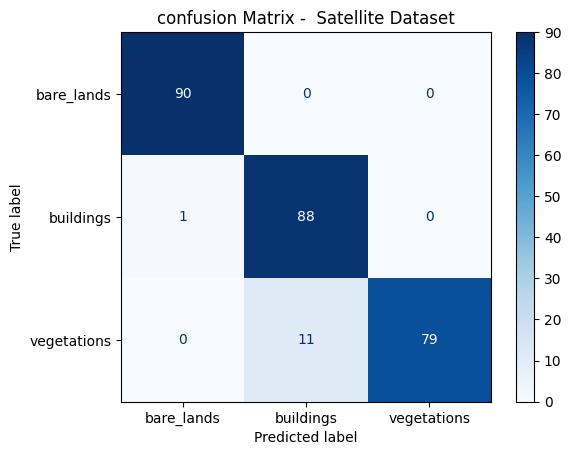

In [21]:
#Confusion matrix for satellite - true labels vs predicted labels
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Collect true labels and predictions
y_true_sat = []
y_pred_sat = []

for images, labels in sat_test:
  preds = sat_model.predict(images)
  y_pred_sat.extend(np.argmax(preds, axis = 1))
  y_true_sat.extend(labels.numpy())

#Create confusion matrix
cm_sat = confusion_matrix(y_true_sat, y_pred_sat)

#Display confusion matrix
disp_sat = ConfusionMatrixDisplay(
    confusion_matrix = cm_sat,
    display_labels = sat_class_names
)

plt.figure(figsize = (6,6))
disp_sat.plot(cmap="Blues", values_format = "d")
plt.title("confusion Matrix -  Satellite Dataset")
plt.show()

Confusion Matrix for Street View Dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 522ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


<Figure size 600x600 with 0 Axes>

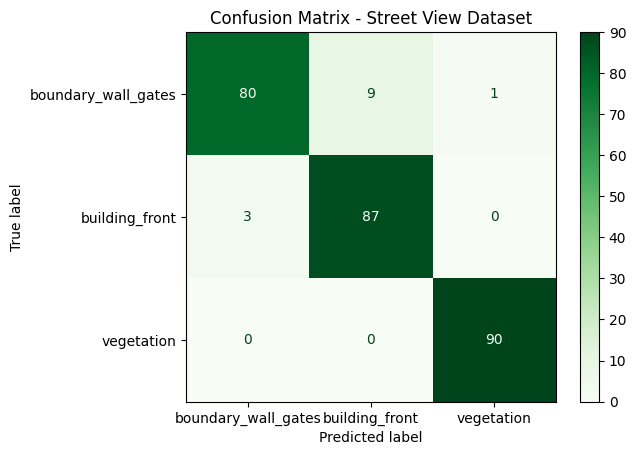

In [25]:
#Confusion matrix for street view dataset - true labels vc predicted labels

#Collect true labels and predictions
y_true_st = []
y_pred_st = []

for images, labels in st_test:
  preds = st_model.predict(images)
  y_pred_st.extend(np.argmax(preds, axis = 1))
  y_true_st.extend(labels.numpy())

#Create confusion matrix
cm_st = confusion_matrix(y_true_st, y_pred_st)

#Display confusion matrix
disp_st = ConfusionMatrixDisplay(
    confusion_matrix = cm_st,
    display_labels = st_class_names
)

plt.figure(figsize = (6,6))
disp_st.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix - Street View Dataset")
plt.show()